# Chapter 5: Spatial Image Enhancement by  Filtering: CONVOLUTION

In Chapter 4, we grouped the spatial domain techniques under two headings:

1) **Point operations**, which changes the color palette of an image, **independent** of the position of a pixel.

2) **Spatial Filtering**, which changes the brightness value of a pixel, **depending** on its position.

We already studied the point operations, in Chapter 4, where we designed a transformation  function from the  colors of the original image to that of the desired image. In this group of techniques, we just change the color pallette of the image without considering the color information of the neighboring pixels. However, it is well-known that the pixel colors  in a predefined neighborhood are related to each other to form shapes and regions. Therefore, it is crucial to design image enhancement methods using the neighborhood information among the pixel groups. Image processing techniques, which accentuate the predefined spatial properties of an image, such as edges, boundaries, smooth regions, textures, is called spatial filtering.

 We devote this chapter to the second group, namely, spatial filtering.

Let's start from the definition of **filter.**

**Motivating Question: What is a filter?**

Loosely speaking, a **filter** is a device, which removes unwanted parts of a substance.

In image processing, a filter is an algorithm, which is developed to remove the unwanted features in an image, according to a predefined goal. The filtered image consists of desired characteristics of the image. Figure 1 shows an original image and its filtered output. In this figure, the goal of filtering is to detect the edges of the original image.

*<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W5/new0_tolu.png" height=300px><figcaption>Figure 1: Filtering can remove the smooth regions in an original image $f(x,y)$ to detect the abrupt changes corresponding to edges at the output, $g(x,y).$ </figcaption></p></figure>*

There is a wide range of methods for filtering an image for blurring, sharpening, detecting the edges and lines etc.

  

One of the basic mathematical tool in the spatial domain is **2-dimensional convolution operation**. In case of multispectral or 3-dimensional images, we may need higher dimensional convolution operations. High dimensional convolution is beyond the scope of this book. However, keep in mind that it is a trivial extension of 1-dimensional convolution.

  


# Two-Dimensional Convolution and Correlation Operations

Loosely speaking, convolution and correlation operations measure the degree of similarity of an image patch to a predefined filter. For example, if we design a filter  which consists of a vertical edge, then the output of the convolution operation highlights the vertical edges of the image.

 Formal definition of convolution and correlation are  defined below.



**Definition: Convolution and Correlation:**  Given a 2-dimensional discrete function, $f(x,y)$ representing a gray scale image and a two dimensional filter $h(x,y)$, **convolution operation** is defined as,

$$g(x,y) = f(x,y)*h(x,y) = \displaystyle\sum_{\forall s} \displaystyle\sum_{\forall t}  h(x-s,y-t) f(s,t),$$

whereas **correlation operation** is defined as,

$$g(x,y) = f(x,y)\star h(x,y) = \displaystyle\sum_{\forall s}  \displaystyle\sum_{\forall t} h(x+s,y+t) f( s, t).$$

- In **convolution equation**, we **flip** the filter function (because of the minus signs) with respect to the origin in $x$ and $y$ direction and slide over the image, as we multiply the overlapping pixels and summing them all up to find the value of the output image, g(x,y), at each pixel location $(x,y)$.

- In **correlation equation**, we **do not flip** the filter, but just slide over the image, as we multiply the overlapping pixels and summing them all up to find the value of the output image, g(x,y).

  

In most practical applications the filter, $h(x,y)$ is symmetric, with respect to the origin pixel, called the **seed pixel**. In this case, flipping the window does not make any change, thus, convolution and correlation operations give the same result. For this reason, from now on we just study convolution, keeping in mind that we may apply correlation operation if the filter is symmetric with respect to the origin.

  

  

Theoretically the limits of the summations ranges in the interval, $(- \infty,+ \infty)$. However, since the function, $f(x,y)$, which represents the image and the mask, $h(x,y)$ have both finite dimensions, the limits of the summations are bounded to their  size.



## Practical Implementation of Convolution for Image Processing

In practice, an image is represented by an $N \times M$ array and a filter has very small size compared to the image size, e.g., $3\times3$ or $5\times5$ or $7\times7$ or slightly bigger.

We can assume that the rest of the values, outside the image and filter are zero. This assumption is called **zero padding**. Sometimes, we assume that the image has a **taurus structure**, meaning that the leftmost and rightmost column are neighbors. Similarly, the top row and the bottom row are neighbors. Then, the limits of the summations are restricted by the image size.

### Selection of the Origin

In order to apply the convolution operation, we need to define an origin for both image and the filter. The origin of the image, $f(0,0)$, is usually assumed to be at the upper-left corner of the image. The origin of the filter, called the seed pixel, depends on the design of the filter. If we design a square filter, we select the seed as the center pixel.

### How does Convolution Work as a Filter?

The convolution operation, given in the above equation looks cumbersome. What does it really do to image? 


For simplicity let's assume that an image and filter is represented by a one dimensional discrete function, $f(x)$ and $w(x)$. One dimensional convolution is, then, defined as;

$$g(x) = f(x)*h(x) = \displaystyle\sum_s h(s) f(x-s),$$

Let's consider the convolution of a truncated exponential function by a box function, as shown in the following animation, taken from Wikipedia:


<img src="https://upload.wikimedia.org/wikipedia/commons/b/b9/Convolution_of_spiky_function_with_box2.gif" width="800" />

  
Note that the output of the  convolution function, $g(x)$ gets high values around the pixels if there is a large overlap with the filter function, because the area under the multiplication of two functions gets large. As the overlap gets small then the area decreases. Then, the convolution output has zero value.

The above brief analysis reveals that convolution operation implicitly measures the degree of similarity between the two functions at each point $x.$

**Exercise:** Convolve a one dimensional image given below,

$$f(x) = [1 \quad 1 \quad 2 \quad 1 \quad 1 \quad 1 \quad 1 \quad 1 \quad 1 \quad ]$$

with the filter


$$h(x) =\frac {1}{4} [1\quad 2 \quad 1].$$

**Answer:**

Assume zero padding, i.e add zeros to the leftmost and rightmost pixels of $f(x)$. Assume that the seed pixel is at the center of the filter.

When we slide the filter over the image, we start putting the seed pixel on top of the leftmost pixel of the image. Then, the leftmost pixel of the window falls outside of the image. For this reason, we extend the image by zero padding to cover the pixels of the filter.

$$f(x) = [0 \quad 1 \quad 1 \quad 2 \quad 1 \quad 1 \quad 1 \quad 1 \quad 1 \quad 1 \quad 0].$$

Since the filter is symmetric, we do not need to flip $h(x)$. The output of convolution is obtained by sliding the filter over the image starting from the leftmost pixel to the rightmost pixel. As the filter moves from the left to the right, we multiply and sum the overlapping pixels to find the value of a pixel under the seed of $h(x)$:

$$g(x) =f(x)*h(x) = [\quad 3/4 \quad 5/4 \quad 6/4 \quad 5/4 \quad 1\quad 1\quad 1\quad 1\quad 3/4 \quad]$$

Note that the value of the output image is highest (6/4), when the filter is exactly the same as that piece of the image. Therefore, the filtered image shows the degree of similarity to the filter at each overlapping set of pixels.

**Motivation Question**: How do we convolve a 2-dimensional image by a 2-dimensional filter?

As we did in 1-dimensional case, we slide the filter over the image by putting the seed pixel on the pixel of the image at the upper left corner. Then, as we slide the filter, we compute the value of $g(x,y) = f(x,y)*h(x,y)$, at each pixel coordinate, $(x,y)$, under the seed pixel (origin) of the window, by multiplying and adding all the multiplications under the window.

  

<img src="https://upload.wikimedia.org/wikipedia/commons/1/19/2D_Convolution_Animation.gif" width="600" />

  



## Convolution as a Spatial Filter

If we define an image, $f(x,y)$ as an input of a linear system represented by the two dimensional impulse response, $h(x,y)$, the output of this system is the image, $g(x,y)$, which is obtained by convolution of $f(x,y)$ and $h(x,y)$ as follows;

$$g(x,y) = f(x,y)*h(x,y).$$

The filter, $h(x,y)$, is, also, called a **mask, kernel, window or template**.


$$f(x,y) \rightarrow\boxed{h(x,y)}\rightarrow g(x,y)=f(x,y)*h(x,y)$$

Figure 1: Schematic representation of convolution operation, as a linear system, represented by the convolution equation, $g(x,y) = f(x,y)*h(x,y)$.


The design of the filter depends on the application domain. Recall that convolution operation highlights the mask structure contained in the image. If a mask is similar to the image in a particular location, then the output pixel under the seed pixel at each image coordinate $(x,y)$, gets a high value.

Loosely speaking, we can say that a filter, $h(x,y)$, passes the local structures of the input image, $f(x,y)$, which are similar to itself to the output image, g(x,y), while suppressing the dissimilar structures.

**Motivating questions**: How do we design a filter?

Designing a filter depends on our goal. It is an art rather than engineering. We need to keep in mind that convolution operation outputs an image where the pixels correspond to the degree of similarity of image to the filter. In other words, the high intensity value of a pixel shows high similarity of that pixel and its neighbors to the convolution mask, whereas the black regions are filtered out by the convolution operation.

There are three major  parameters to design a filter:

**1. Size of the filter:** If the window is needed to filter large patches in the image, the size should be relatively large.

**2. The shape of the filter:** Most of the filters are square shaped where the origin is selected at the center. Occasionally we may design filters in a rectangular, diamond or cross shaped.

**3. Entries of the filter:** If we need to blur an image, we suppress abrupt changes and pass the relatively smooth areas. Thus, we design a filter with similar entries. If we need to detect the abrupt changes, the entries of the filter should have opposite signs to emphasize the differences among the neighboring pixels.

In the following, we shall study some popular filters:

  



### 1. Smoothing Filters

There are many smoothing filters with different sizes and entries.
Simplest smoothing filter is of size $3\times3$

$$h_0= \frac{1}{9} \begin{bmatrix}1 & 1 & 1 \\1 & \boxed1 & 1 \\1 & 1 & 1 \\\end{bmatrix}.$$

In a smoothing filter the seed pixel is defined as the center pixel (in the box). The above filter takes the arithmetic average of all the pixels in the $3\times3$ window and assigns it to the image pixel under the seed.

*<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W5/orig5.png" height=150px><figcaption>Figure 2: a) Original Image. Filtered image by filter $w_0$ of size, b) 5x5 and c) 7x7. Notice that as the filter size gets larger, the image gets more blurry. ( Photo from METU, by Ömer Yağız)</figcaption></p></figure>*

  

**Note:** $\boxed1$ is seed pixel (origin of the filter).

  

If we are willing to accentuate the color of each pixel more then its neighboring pixels, in the original image, as we smooth, we can give higher values to the seed pixel of the filter:

  

  

$$h_1= \frac{1}{10} \begin{bmatrix}1 & 1 & 1 \\1 & 2 & 1 \\1 & 1 & 1 \\\end{bmatrix}, \quad h_2= \frac{1}{14} \begin{bmatrix}1 & 2 & 1 \\1 & 4 & 1 \\1 & 2 & 1 \\\end{bmatrix}.$$

  

*<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W5/orig4.png" height=300px><figcaption>Figure 3: a) Original Image. Filtered image by $w_1$ and $w_2$ of size b) 3x3, c) 5x5 and d) 7x7. Note that the output of the second filter is relatively less blurred compared to that of the first filter.</figcaption></p></figure>*











Comparing Figures 2 and 3 reveals that both filters blur the image. However, Figure 3 preserves the colors of the image more than that of Figure 2.

  

Depending on the application, we can design larger sized filters. As we increase the size of the smoothing filters we get more blur.

  

**Exercise:** Consider the following image patch,

  

$$f(x,y) = \begin{bmatrix}1 & 1 & 1 &1 & 1 & 1 \\1 & 1 & 1 &1 & 1 & 1\\1 & 1 & 1 &1 & 1 & 1\\1& 2 & 1 & 5 & 1 & 5 \\1 & 1 & 1 & 7 & 2 & 5\\\end{bmatrix}$$

  

and the masks

  

  

$$h_0= \frac{1}{9} \begin{bmatrix}1 & 1 & 1 \\1 & 1 & 1 \\1 & 1 & 1 \\\end{bmatrix}, quad h_1= \frac{1}{10} \begin{bmatrix}1 & 1 & 1 \\1 & 2 & 1 \\1 & 1 & 1 \\\end{bmatrix}.$$


Find the resulting image outputs,

$g_0(x,y) = f(x,y)*h_0(x,y)$ and $g_1(x,y) = f(x,y)*h_1(x,y),$

assuming taurus structure for the image, $f(x,y)$. In order to obtain a digital output image round the non-integer values.

**Answer:**

$g_0(x,y) = f(x,y)*h_0(x,y) = \begin{bmatrix}0 & 1 & 1 &1 & 1 & 0 \\1 & 1 & 1 &1 & 1 & 1\\1 & 1 & 2&1 & 2 & 1\\1& 1 & 2 & 2 & 3 & 2 \\1 & 1 & 2 & 2 & 3 & 1\\\end{bmatrix},$

  
  

$g_1(x,y) = f(x,y)*h_1(x,y) = \begin{bmatrix}1 & 1 & 1 &1 & 1 & 1 \\1 & 1 & 1 &1 & 1 & 1\\1 & 1 & 2&1 & 2 & 1\\1& 1 & 2 & 3 & 3 & 2 \\1 & 1 & 2 & 2 & 3 & 2\\\end{bmatrix},$



**Programming exercises:**

1.   Run the following code to see the output of average filtering.
2.   Change the kernel size to (20, 20) and apply the filter on the checkerboard image.

(-0.5, 199.5, 199.5, -0.5)

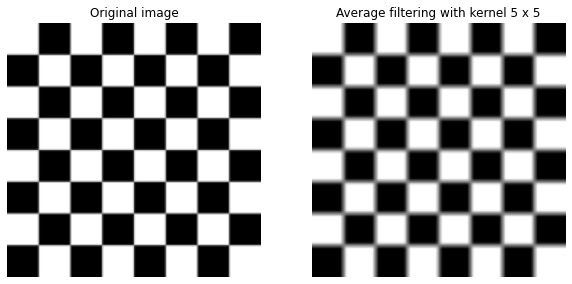

In [ ]:
# Average filtering

from skimage import data
import matplotlib.pyplot as plt
import numpy as np
import scipy.ndimage.filters


img = data.checkerboard().astype(float)

kernel1 = np.ones((5,5))
img_kernel1 = scipy.ndimage.filters.convolve(img, kernel1) 

fig, axes = plt.subplots(ncols=2, figsize=(10, 5))
ax = axes.ravel()

ax[0].imshow(img, cmap=plt.cm.gray)
ax[0].set_title('Original image')
ax[0].axis('off')

ax[1].imshow(img_kernel1, cmap=plt.cm.gray)
ax[1].set_title('Average filtering with kernel 5 x 5')
ax[1].axis('off')






### 2. Gaussian Filter

[Gaussian function](https://en.wikipedia.org/wiki/Gaussian_function) is a very important function, which is widely used in science and engineering.

In image processing, we use a specific form of 2-dimensional Gaussian function, given below:

$$h(x,y)= \frac{1}{2\pi\sigma^2}exp[\frac{-1}{2\sigma^2}(x^2+y^2)].$$

The cross section of the above function is circular. The parameter $\sigma^2$ is called the **variance** and it shapes the Gaussian function. As $\sigma$ gets larger, the function becomes wider.

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W5/image8.png" height=300px><figcaption>Figure 4: Two-dimensional Gaussian function is a bell shaped continuous function. </figcaption></p></figure>

In order to define a Gaussian filter, we need to sample and quantize the two-dimensional continuous Gaussian function. The sampling and quantization rates define the size and entries of the Gaussian Filter. If we need a small Gaussian filter, say, a $3\times 3$ window, then we select 9 samples from the Gaussian function, at ($x,y)$ coordinates. Then, we round the corresponding real number of $h(x,y)$ to an integer. Obviously, a $3\times 3$ Gaussian filter is not a poor approximation of the continuous time Gaussian Function. We can increase the size of the filter to get a better approximation.




Two popular Gaussian filters are given below:

  

  

$$h_1(x,y)= \frac{1}{16}\begin{bmatrix} 1 & 2 & 1 \\ 2 & 4 & 2 \\ 1 & 2 & 1\end{bmatrix},\quad \quad h_2(x,y) = \frac{1}{273}\begin{bmatrix} 1 & 4 & 7 &4&1 \\ 4&16&26&16&4 \\ 7&26&41&26&7 \\ 4&16&26&16&4 \\1 & 4 & 7 &4&1 \end{bmatrix}.$$


*<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W5/orig7.png" height=200px><figcaption>Figure 5: a) Original Image. Filtered image using b) $w_1$ and c) $w_2.$</figcaption></p></figure>*


> **Q:** Study [edge smoothing](https://scc.ustc.edu.cn/zlsc/tc4600/intel/2017.0.098/ipp/common/ipp_manual/GUID-3020FC0C-FEF0-420C-B430-DD35F1BF8357.htm), inverse gradient and rotching masks



Since Gaussian function is symmetric, with respect to the maximum value, we select the seed pixel at the origin.

**Programming exercises:**

1.   Run the following code to see the output of Gaussian filtering.
2.   Change sigma to 10 and apply the filter on the checkerboard image.

(-0.5, 199.5, 199.5, -0.5)

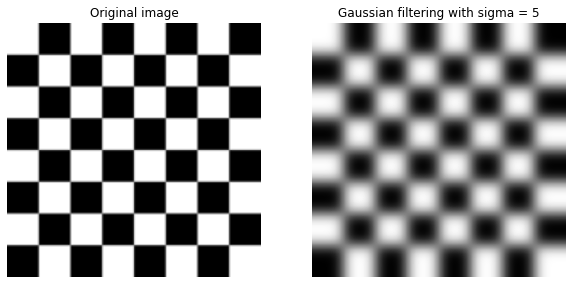

In [ ]:
# Gaussian filtering

from skimage import data
import matplotlib.pyplot as plt
import numpy as np
import scipy.ndimage.filters

img = data.checkerboard().astype(float)

img_filter1 = scipy.ndimage.gaussian_filter(img, sigma=5)
fig, axes = plt.subplots(ncols=2, figsize=(10, 5))
ax = axes.ravel()

ax[0].imshow(img, cmap=plt.cm.gray)
ax[0].set_title('Original image')
ax[0].axis('off')

ax[1].imshow(img_filter1, cmap=plt.cm.gray)
ax[1].set_title('Gaussian filtering with sigma = 5')
ax[1].axis('off')



### 3. Median Filters

Median filters are nonlinear filters, which assign the median value to an image pixel, under the seed of the filter, defined over a window.

>**Algorithm: Median Filtering**
>>
>>1. Define a window of size $n\times m$, where $n$ and $m$ are small compared to the image size.
>>
>>2. Slide the window over the image and at each move compute the median value of the window.
>>
>>3. Assign the pixel brightness value at the center of the window (seed) as median.

  

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W5/new1.png" height=500px><figcaption>Figure 6: Finding the median value of a window and assigning it to the center pixel. The brightness value, 255, of the original image is changed by the median (96) of the window </figcaption></p></figure>

  
  
  

  

**Example**: Find the median filtered output of the following image for the window size $3\times3$:


$f(x,y) = \begin{bmatrix}1 & 1 & 1 &1 & 1 & 1 \\1 & 2 & 1 &1 & 3 & 1\\1 & 1 & 1 &1 & 1 & 1\\1& 2 & 1 & 5 & 1 & 1 \\1 & 1 & 1 & 1 & 1 & 1\\\end{bmatrix},$


Click here to see the answer

Assume taurus structure for the image.

answer:

$g(x,y) = \begin{bmatrix}1 & 1 & 1 &1 & 1 & 1 \\1 & 1 & 1 &1 & 1 & 1\\1 & 1 & 1 &1 & 1 & 1\\1& 1 & 1 & 1 & 1 & 1 \\1 & 1 & 1 & 1 & 1 & 1\\\end{bmatrix},$

Notice that the median filter is very useful to remove sand-like noise.

  

*<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W5/new2.png" height=300px><figcaption>Figure 7: An image with sand-like noise and its median filtered output.</figcaption></p></figure>*



**Programming exercises:**

1.   Run the following code to see the output of median filtering.
2.   Change the amount of noise to 0.5 and visualize the output.
3.   Change the kernel size to (20,20) and apply the median filter.

(-0.5, 49.5, 49.5, -0.5)

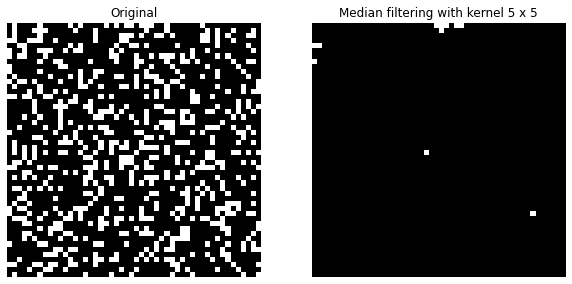

In [12]:
# Median filtering
from skimage import data
import matplotlib.pyplot as plt
import numpy as np
from skimage.filters import median 
from skimage.morphology import square
from skimage.util import random_noise

img = np.zeros([50,50],dtype=np.uint8)
noisy_img = random_noise(img, seed=2, mode='salt', amount=0.25)

kernel1 = np.ones((5,5))

img_kernel1 = median(noisy_img, kernel1)

fig, axes = plt.subplots(ncols=2, figsize=(10, 5))
ax = axes.ravel()

ax[0].imshow(noisy_img, cmap=plt.cm.gray)
ax[0].set_title('Original')
ax[0].axis('off')

ax[1].imshow(img_kernel1, cmap=plt.cm.gray)
ax[1].set_title('Median filtering with kernel 5 x 5')
ax[1].axis('off')



### 2. Sharpening Filters: Edge Detectors

In this section, we design filters to detect the edges in an image.

Recall that edges are pixels, where brightness changes abruptly in at least one of the neighboring pixels, defined in a neighborhood system. It is a vector variable with;

1) Magnitude

2) Direction

Edges provide important information about the shape of the objects. Therefore, detecting the edges is an important image processing problem.

**Motivating Question:** How do we detect the edges in an image?

Calculus provides us an important tool to detect the abrupt changes in functions: **Derivatives!**

  

Let’s recall the derivatives in 2-dimensional continuous functions, then extend the idea to the discrete functions, as **differences**.



#### Derivative Operations Defined for Continuous Functions

  

For simplicity, let us consider a one dimensional function which represents edges.

  

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W5/images.png" height=300px><figcaption>Figure 8: Edge profiles in a continuous one dimensional image. a) Ideal edge, b) roof edge, c) line and d) noisy edge, which is the case in most of the images.</figcaption></p></figure>

  

  
  
  

  

In order to detect the edges, in a two dimensional continuous function, we employ Gradient (first derivative) and Laplacian (second derivative)

  

  

**Definition: Gradient of a two dimensional function $f(x,y)$** is defined as the first derivative, given below;

  
  

$$\nabla f(x,y) = \begin{bmatrix}\frac{\partial f}{\partial x} \\ \\\frac{\partial f}{\partial y}\end{bmatrix},$$

  

where the magnitude is defined as,

  

$$|\nabla f|= \sqrt{\frac{\partial f}{\partial x}^2+ \frac{\partial f}{\partial y}^2}$$

  

and direction is defined as,

  

$$\Psi = tan^{-1} (\frac{\frac{\partial f}{\partial y}}{\frac{\partial f}{\partial x}}) , radians$$

  

  

**Definition: Laplacian of a two dimensional function $f(x,y)$** is defined as the second derivative, defined below;

  

$$\nabla^2 f(x,y) = \frac{\partial^2 f}{\partial x^2}+\frac{\partial^2 f}{\partial y^2}.$$

  

  

**Fact: : Although the gradient operation has a direction, the Laplacian operation does not have any direction. Thus, Laplacian operation invariant to rotation**. When the direction of an edge is important, we use gradient operation. If we are just interested in detecting the edge pixels, we use Laplacian operation.

  

  

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W5/image6new.png" height=400px><figcaption>Figure 9: An ideal edge is indicated by a step function (upper left). The gradient of an ideal edge is just an impulse at the discontinuity of the step function (upper right). In practice, an edge does not appear as an ideal step function. It has a rather smooth change, such as a ramp function (lower left). In this case, the gradient becomes a sharp bump around the ramp (lower right).</figcaption></p></figure>

  
  
  
  
  

  

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W5/ramp.png" height=300px><figcaption>Figure 10: a) Ramp function and b) Laplacian of ramp function. </figcaption></p></figure>

  

  

> Q: Discuss the advantages and disadvantages of Gradient and Laplacian to detect the edges.



#### Difference Operations Defined for Discrete Functions

In practice, we have barely a continuous image. Therefore, the above continuous gradient and Laplacian functions cannot be used for digital images.

**Definition: First Difference operation** is defined as follows:

First difference in x-direction: $\nabla_x f(x,y) = f(x,y) - f(x\mp1,y)$

First difference in y-direction: $\nabla_y f(x,y) = f(x,y) - f(x,y\mp1)$

First difference in diagonal direction:$\nabla_{xy} f(x,y) = f(x,y) - f(x\mp1,y\mp1).$

**Fact**: First difference operations defined above approximates the first derivative operations, taken in $x,y$ and diagonal directions.



## Gradient Filters (First Derivative Filters)

The above first difference operators can be implemented by convolution of an image with **first derivative** filters to detect the edges in various directions.

**Goal:** Design a mask, which approximates the **first derivative operations**, by the first difference operations, such that convolving an image with the filter outputs an edge mask of the original image.


There is a wide range of filters suggested in the image processing literature, which approximate the continuous first derivative operations by the discrete first difference operations. When convoluted by the original image, these filters output an edge map of the image. In the following, we provide some examples of first derivative filters.



#### 1. Roberts Filters

The simplest first derivative filters are defined by the following 2-dimensional arrays for left and right diagonal directions,

$h_{ld} = \begin{bmatrix} 1 & 0 \\ 0 & -1\end{bmatrix}$, $h_{rd} = \begin{bmatrix} 0 & 1 \\ -1 & 0\end{bmatrix},$

and for horizontal end vertical directions,

$h_{h} = \begin{bmatrix} 1 & 1 \\ -1 & -1\end{bmatrix}$, $h_{v} = \begin{bmatrix} 1 & -1 \\ 1 & -1\end{bmatrix}.$ 

**Fact:** Convolution of the above Roberts filters with an image is equivalent to finding the first differences among the two neighboring pixels of the original image.

  
  

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W5/roberts.png" height=800px><figcaption>Figure 11: First derivative filters. a) Original image, b, c) Vertical and horizontal Roberts filter , d,e ) Diagonal Roberts filters.
</figcaption></p></figure>


### 2.Prewitt Filters

Roberts filters detect the very fine edges. If we need to detect the ticker edges, we need to enlarge the filter size, by defining Prewitt filters, as follows:

$h_{h} =\begin{bmatrix} 1 & 1 & 1 \\ 0 & 0 & 0 \\ -1 & -1 & -1\end{bmatrix}\quad$, $h_{v} =\begin{bmatrix} -1 & 0 & 1 \\ -1 & 0 & 1 \\ -1 & 0 & 1\end{bmatrix}$,

$h_{ld} = \begin{bmatrix} 0 & -1 & -1 \\ 1 & 0 & -1 \\ 1 & 1 & 0\end{bmatrix}\quad$, $h_{rd} = \begin{bmatrix} 0 & 1 & 1 \\ -1 & 0 & 1 \\ -1 & -1 & 0\end{bmatrix}.$

  
  
  
  
  
  

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W5/prewitt.png" height=600px><figcaption>Figure 12: First derivative filters. b, c) Vertical and horizontal Prewitt filter , d,e ) Diagonal Prewitt filters of the image given in Figure 11.</figcaption></p></figure>

  



### 3. Sobel Filters

  

Sobel filters combine the edge maps, obtained at the output of gradient filters in vertical and horizontal directions to define the magnitude and directions of edge pixels.

Let us, first, approximate the vertical and horizontal filters by the following windows;

  

$$h_{v} =\begin{bmatrix} -1 & 0 & 1 \\ -2 & 0 & 2 \\ -1 & 0 & 1\end{bmatrix},\quad h_{h} =\begin{bmatrix} 1 & 2 & 1 \\ 0 & 0 & 0 \\ -1 & -2 & -1\end{bmatrix}.$$

  

We convolve an image by both vertical and horizontal filters, defined above, to obtain the horizontal and vertical edge maps, as follows;

$$g_h(x,y) = f(x,y) * h_h(x,y), \quad g_v(x,y) = f(x,y) * h_v(x,y).$$

Using the vertical and horizontal edge maps $g_h(x,y)$ and $g_v(x,y)$, we can define a new edge map, called **Sobel edge map**, where the magnitude of an edge pixel is computed by,

$$|g(x,y)| = \sqrt{g_h^2(x,y) +g_ v^2(x,y)}, $$

and direction of an edge pixel is computed by,

$$\Theta (x,y) = \arctan{\frac{ g_v(x,y)}{g_h(x,y)}}.$$

  <figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W5/sobel.png" height=300px><figcaption>Figure 13: First derivative filters. b, c) Vertical and horizontal Sobel  filters of the image given in Figure 11.</figcaption></p></figure>



**Programming exercises:**

1.   Run the following code to see the outputs of different edge detectors.

(-0.5, 588.5, 812.5, -0.5)

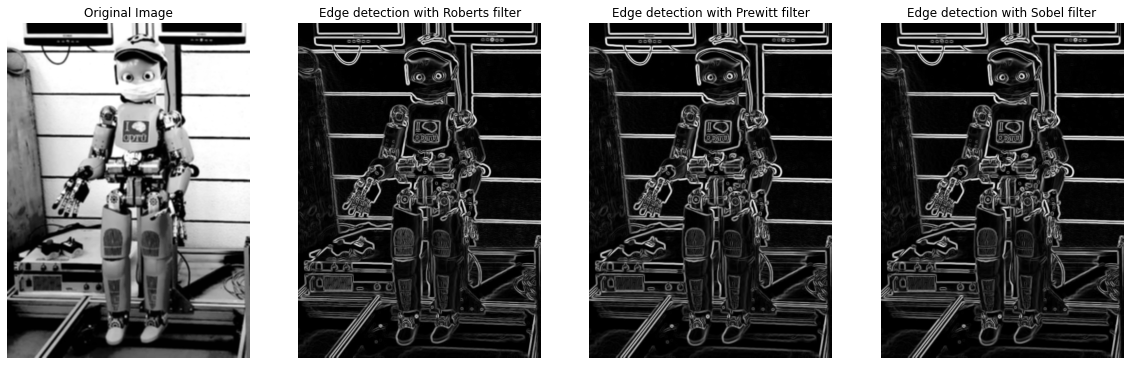

In [15]:
# Edge detection using Roberts, Prewitt, and Sobel filters
from skimage import data
from skimage import filters
img = data.camera()

################ EDITED PART #############
from skimage import io
!wget -cq https://raw.githubusercontent.com/hazalmogultay/466Images/master/W5/robot.png
img = io.imread('robot.png')
##########################################

roberts_img = filters.roberts(img)
prewitt_img = filters.prewitt(img)
sobel_img = filters.sobel(img)

############### EDITED PART #########################
#fig, axes = plt.subplots(ncols=3, figsize=(20, 8))
fig, axes = plt.subplots(ncols=4, figsize=(20, 8))
ax = axes.ravel()


ax[0].imshow(img, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(roberts_img, cmap=plt.cm.gray)
ax[1].set_title('Edge detection with Roberts filter')
ax[1].axis('off')

ax[2].imshow(prewitt_img, cmap=plt.cm.gray)
ax[2].set_title('Edge detection with Prewitt filter')
ax[2].axis('off')

ax[3].imshow(sobel_img, cmap=plt.cm.gray)
ax[3].set_title('Edge detection with Sobel filter')
ax[3].axis('off')
##################################################


#### Laplacian Filters (Second Derivative Filters)

  

Similarly, we can define second derivative filters, such that the convolution of an image with the filter approximates taking the second derivative of a two dimensional image function.

  

**Note:** Second derivative filters are independent of direction. Therefore, the filter just takes the difference between the center pixel and its neighboring pixels.

### 1- Laplacian Filters as Edge Detectors

  

  

The size and the entry values of the second derivative filters depend on the sampling and quantization method of the continuous Laplacian function. Two popular Laplacian filters are defined as follows:

  



$$h_{l1} = \begin{bmatrix} 0 & 1 & 0 \\ 1 & -4 & 1 \\ 0& 1 & 0\end{bmatrix} ,\quad h_{l2}= \begin{bmatrix} 1 & 1 & 1 \\ 1 & -8 & 1 \\ 1& 1 & 1\end{bmatrix}.$$

  

*<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W5/orig2.png" height=400px><figcaption>Figure 14: Original image and its filtered output by Laplacian filters a) $w_{l1}$ and b) $w_{l2}$  of the image given in Figure 11.</figcaption></p></figure>*

  
  

  

### Laplacian of Gaussian Filter as Edge Detectors

  

  

Recall the bell shaped 2-dimensional continuous Gaussian function which is employed for smoothing images,

  

$$h(x,y)= \frac{1}{2\pi\sigma^2}exp[\frac{-(x^2+y^2)}{2\sigma^2}].$$

  

The Laplacian of the Gaussian function provides a smooth edge detector. In other words, if we take the second derivative of the Gaussian function we obtain a mexican hat cross section shape, as follows;

  

  

$$\nabla^2 h(x,y) = \frac{1}{2\pi\sigma^2}(\frac{x^2+y^2-\sigma^2}{\sigma^4} )exp[- \frac{x^2+y^2}{2\sigma^2}].$$

  

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W5/image9.png" height=300px><figcaption>Figure 15: The cross section of the Laplacian of Gaussian Function, in the shape of Mexican Hat. </figcaption></p></figure>

  

  
  
  

  

If we convolve an image with Laplacian of Gaussian filter, we obtain the following edge map;

  

  

$$\nabla^2(h\ast f)=\nabla^2 h\ast f.$$

  

  

The next step is to sample and quantize the 2-dimensional continuous Laplacian of Gaussian function, $\nabla^2(G\ast f)$ to obtain the Laplacian of Gaussian Filter. Depending on the sampling and quantization rate we can obtain different size and entry values for the filter. Two popular Laplacian of Gaussian filter is given below:

  

  

$$h_{lg1}=\begin{bmatrix} 0 & -1 & 0 \\ -1 & 4 & -1 \\ 0 & -1 & 0\end{bmatrix}\quad \quad h_{lg2} = \begin{bmatrix} 0 & 0 &-1 & 0&0 \\ 0&-1&-2&-1&0\\-1&-2&16&-2&-1\\0&-1&-2&-1&0\\0&0&-1&0&0\end{bmatrix}.$$

  

*<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W5/orig1.png" height=400px><figcaption>Figure 16: Original Image and the output of the Laplacian of Gaussian Filters for a) $w_{lg1}$ and $w_{lg2}$ of the image given in Figure 11.</figcaption></p></figure>*

  



(-0.5, 588.5, 812.5, -0.5)

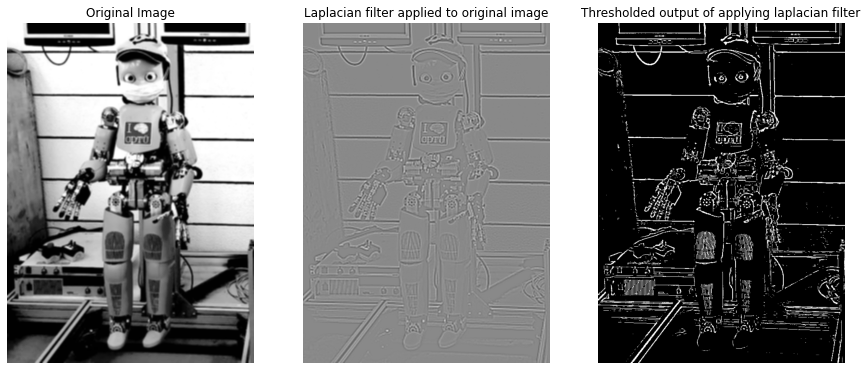

In [40]:
# Edge detection using Laplacian filter
from skimage import data
from skimage import filters
from skimage.filters import threshold_otsu
laplace_img = filters.laplace(img)
thresh = threshold_otsu(laplace_img)
binary = laplace_img < thresh

fig, axes = plt.subplots(ncols=3, figsize=(15, 8))
ax = axes.ravel()

ax[0].imshow(img, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(laplace_img, cmap=plt.cm.gray)
ax[1].set_title('Laplacian filter applied to original image')
ax[1].axis('off')

ax[2].imshow(binary, cmap=plt.cm.gray)
ax[2].set_title('Thresholded output of applying laplacian filter')
ax[2].axis('off')


## Canny Edge Detectors

  

Canny edge detectors combine a series of convolution and thresholding operations to ampirically satisfy the **law of continuity and law of closure of Gestalt theory.**

  

We have seen that our Human visual system smooths the data coming from the physical world in the retina by rods and cones. This operation is heuristically approximated by applying a Gaussian smoothing filter. One of the edge detection methods, such as Sobel, mentioned above, is applied after the smoothing process. The law of continuity is heuristically approximated by a method, called non-maximal suppression. In this step, the weak edges around a large magnitude pixel are removed, if they have the same direction with a high magnitude pixel. The law of closure is heuristically approximated by double thresholding and edge tracking, where weak edges are connected to the strong edges if they have the same directions.

  

>**Algorithm: Canny Edge Detection**
>>
>>1. Smooth the image by a **[Gaussian filter](https://en.wikipedia.org/wiki/Gaussian_filter)** in order to remove the noise embedded in the image.
>>
>>2. Find the edge map of the smoothed image, using **Sobel edge detector**.
>>
>>3. Non-maximal suppression: Remove the weak edges by comparing the magnitude of the pixel with that of the pixel in the positive and negative gradient directions:
>>If the magnitude is large compared to the other pixels in the same direction, then, preserve it. Otherwise, delete it.
>>
>>4. Double thresholding: When the gradient value of a pixel is higher than a predefined high threshold value $T_1$, label it as **strong edge**. When the gradient value of a pixel is lower than a predefined low threshold value $T_2$, label it as **weak edge**.
>>
>>5. Track edge by [hysteresis](https://en.wikipedia.org/wiki/Hysteresis): Finalize the detection of edges by suppressing all the other edges that are **weak and not connected to strong edges**.

# Chapter Conclusion

How can we extract a predefined set of properties from an image? How can we remove the noise embedded in an  image? How can we extract the  edges, which may lie on the  object boundaries? How can we design and implement algorithms to filter out the undesired portion of images?

The answer to the above questions lies  in a very important method, called filtering.In this chapter we saw a popular operation for image filtering, called convolution. We observe that 2-dimensional convolution of an image by a prescribed mask accentuates the resemblance of the image to the mask. We investigated the methods for designing and implementing the filters to smooth and sharpen images. 




In [ ]:
%%HTML

<figure><p align="center"> <iframe width="560" height="315" src="https://www.youtube.com/embed/17cOHpSaqi0" frameborder="0" allow="accelerometer; autoplay; encrypted-media; gyroscope; picture-in-picture" allowfullscreen></iframe></p> <figcaption>Video: Canny Edge detectors. </figcaption></figure>